# SuStaIn applicato a FDG-PET in SLA
## Notebook template con dati sintetici

**Autore**: Fedele  
**Versione**: 1.1  
**Riferimento**: Young et al. *Nature Communications* 2018; Aksman et al. *SoftwareX* 2021

---

### Come usare questo notebook

Questo notebook ha due scopi:

1. **Didattico / dimostrativo**: i dati usati sono *sintetici* (generati artificialmente), con una struttura realistica modellata sul dataset ALS reale del progetto. Ogni cella è commentata per spiegare cosa fa e perché. Puoi eseguirlo dall'inizio alla fine anche senza dati reali.

2. **Template per i dati reali**: quando la pipeline MATLAB (Steps 1–7) sarà completata, basterà sostituire la sezione **"CARICAMENTO DATI"** con il vero file CSV degli z-score ROI. Il resto del notebook non cambia.

### Struttura del notebook

```
0. Setup e import
1. Il dataset sintetico — struttura e variabili cliniche
2. Esplorazione dei dati (z-score ROI)
3. Configurazione di SuStaIn
4. Fitting del modello (Analisi 2a — dataset completo)
5. Convergenza MCMC
6. Selezione del numero ottimale di sottotipi (CVIC)
7. Interpretazione — Positional Variance Diagrams
8. Staging e subtyping dei pazienti
9. Analisi post-hoc: correlazioni cliniche
10. Analisi 2b — C9orf72 isolato
11. Analisi 2d — Validazione biologica SOD1
12. [SEZIONE DA COMPLETARE] Sostituzione con dati reali
```

---

### Contesto biologico

La **SLA (Sclerosi Laterale Amiotrofica)** è una malattia neurodegenerativa che colpisce i neuroni motori. Le forme genetiche più frequenti includono:
- **C9orf72** (~70 soggetti nel dataset): forma più comune, fenotipo variabile da motorio puro ad ALS-FTD
- **SOD1** (~20 soggetti): unica forma senza patologia TDP-43, fenotipo prevalentemente motorio
- TARDBP, FUS, altre forme rare

La **FDG-PET** misura il metabolismo glucidico cerebrale. La patologia in SLA causa **ipometabolismo** nelle regioni coinvolte. Questo notebook modella l'ipometabolismo come z-score rispetto a controlli sani (ADNI), con segno invertito: z-score **positivi** = più patologico.

## Cella 0 — Setup e import

Importiamo le librerie necessarie e configuriamo le cartelle di output.

**Librerie usate:**
- `numpy`, `pandas`: manipolazione dati
- `matplotlib`, `seaborn`: grafici
- `scipy.stats`: test statistici nelle analisi post-hoc
- `sklearn.model_selection`: StratifiedKFold per la cross-validation
- `pySuStaIn`: l'algoritmo SuStaIn vero e proprio

Se `pySuStaIn` non è installato:
```bash
pip install pySuStaIn
```

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle
import os
from pathlib import Path
from scipy import stats
from scipy.stats import spearmanr, mannwhitneyu, kruskal
import sklearn.model_selection
import pySuStaIn

# Seed per riproducibilità dei dati sintetici
np.random.seed(42)

# Cartella di output per i file pickle di SuStaIn
OUTPUT_FOLDER = 'output_sustain_als'
DATASET_NAME  = 'ALS_FDG_synthetic'
Path(OUTPUT_FOLDER).mkdir(exist_ok=True)

print('Import completati.')
print(f'pySuStaIn versione: {pySuStaIn.__version__}')

Import completati.


AttributeError: module 'pySuStaIn' has no attribute '__version__'

---
## Cella 1 — Il dataset sintetico

### Struttura del dataset reale

Il dataset ALS reale del progetto include:

| Gruppo | N (atteso) | Note |
|--------|-----------|------|
| C9orf72 | ~70 | Forma più comune; fenotipo variabile |
| SOD1 | ~20 | Solo validazione biologica (non entra in SuStaIn) |
| TARDBP | ~15 | Solo analisi descrittiva |
| FUS | ~10 | Solo analisi descrittiva |
| Sporadica | ~1085 | Forma senza mutazione genetica identificata |
| **Totale** | **~1200** | |

**Variabili cliniche disponibili**: ALSFRS-R baseline, sede di insorgenza (bulbare/spinale), durata di malattia, ECAS (cognitivo), NfL plasmatico, ptau217, ptau181 (subset).

### Le 19 ROI (atlante AAL)

L'input a SuStaIn è una matrice di z-score medi per ROI, estratta dallo Step 7 della pipeline MATLAB. Le ROI coprono i domini rilevanti per ALS:

| Dominio | ROI | Razionale |
|---------|-----|-----------|
| Motorio | PreCentrale_sin, PreCentrale_dx, SMA | Core ALS |
| Prefrontale | FrontMedio_sin, FrontMedio_dx, OFC | C9orf72, ALS-FTD |
| Cingolato | Cing_ant, Cing_post | Marcatore cognitivo |
| Temporale | Temp_sup_sin, Temp_sup_dx, Temp_medio | ALS-FTD |
| Parietale | Pariet_sup_sin, Pariet_sup_dx | Cluster CPT |
| Subcorticale | Talamo_sin, Talamo_dx | Stadio avanzato |
| Cerebellare | Cerv_sup, Cerv_inf | C9orf72, forme rare |

### Come sono strutturati i dati sintetici

Generiamo 3 sottotipi con sequenze di progressione diverse, ispirate alla letteratura ALS:
- **Sottotipo 1 (Motorio puro)**: ipometabolismo inizia nelle aree motorie, si estende lentamente
- **Sottotipo 2 (Fronto-motorio)**: ipometabolismo coinvolge precocemente anche il frontale e cingolato
- **Sottotipo 3 (Diffuso/CPT-like)**: pattern diffuso con coinvolgimento cerebellare precoce

I soggetti SOD1 sintetici vengono generati *separatamente* con il pattern del Sottotipo 1 (motorio puro), per replicare il loro ruolo di controllo positivo biologico.

In [5]:
# ==============================================================
# DEFINIZIONE DELLE ROI
# Queste etichette corrispondono alle ROI dell'atlante AAL
# che verranno estratte dallo Step 7 della pipeline MATLAB
# ==============================================================

ROI_LABELS = [
    # Motorio (core ALS)
    'PreCentrale_sin', 'PreCentrale_dx', 'SMA',
    # Prefrontale
    'FrontMedio_sin', 'FrontMedio_dx', 'OFC',
    # Cingolato
    'Cing_ant', 'Cing_post',
    # Temporale
    'Temp_sup_sin', 'Temp_sup_dx', 'Temp_medio',
    # Parietale
    'Pariet_sup_sin', 'Pariet_sup_dx',
    # Subcorticale
    'Talamo_sin', 'Talamo_dx',
    # Cerebellare
    'Cerv_sup', 'Cerv_inf',
    # Occipitale (controllo negativo atteso)
    'Occipitale',
    # Insulare
    'Insula'
]

N_ROI = len(ROI_LABELS)

# Indici per dominio (utili per i grafici)
IDX_MOTORIO    = [0, 1, 2]
IDX_PREFRONT   = [3, 4, 5]
IDX_CINGOLATO  = [6, 7]
IDX_TEMPORALE  = [8, 9, 10]
IDX_PARIETALE  = [11, 12]
IDX_SUBCORTIC  = [13, 14]
IDX_CEREBB     = [15, 16]
IDX_ALTRO      = [17, 18]

print(f'ROI totali: {N_ROI}')
print('\nLista ROI:')
for i, r in enumerate(ROI_LABELS):
    print(f'  [{i:2d}] {r}')

ROI totali: 19

Lista ROI:
  [ 0] PreCentrale_sin
  [ 1] PreCentrale_dx
  [ 2] SMA
  [ 3] FrontMedio_sin
  [ 4] FrontMedio_dx
  [ 5] OFC
  [ 6] Cing_ant
  [ 7] Cing_post
  [ 8] Temp_sup_sin
  [ 9] Temp_sup_dx
  [10] Temp_medio
  [11] Pariet_sup_sin
  [12] Pariet_sup_dx
  [13] Talamo_sin
  [14] Talamo_dx
  [15] Cerv_sup
  [16] Cerv_inf
  [17] Occipitale
  [18] Insula


In [6]:
# ==============================================================
# GENERAZIONE DEL DATASET SINTETICO
# ==============================================================
# 
# Ogni paziente ha:
#   - Un sottotipo (1, 2 o 3)
#   - Uno stadio SuStaIn vero (0 = nessuna patologia, fino a N_ROI*3)
#   - Z-score per ogni ROI (calcolati dalla sequenza del suo sottotipo + rumore)
#
# La logica: se un paziente è allo stadio k, significa che k eventi
# z-score si sono verificati secondo la sequenza del suo sottotipo.
# Gli eventi non ancora raggiunti hanno z-score vicino a 0 (+ rumore).
# ==============================================================

def generate_als_synthetic_data(
        n_subtype1=70,   # Motorio puro (simile C9orf72 motorio + sporadico motorio)
        n_subtype2=80,   # Fronto-motorio (C9orf72 cognitivo + sporadico FT)
        n_subtype3=30,   # Diffuso/CPT-like
        n_sod1=20,       # SOD1 (solo validazione — generati separatamente)
        noise_sd=0.8,    # Rumore gaussiano (tipico per dati PET z-scored)
        seed=42
):
    """
    Genera un dataset sintetico di z-score ROI per pazienti ALS.
    
    La struttura dei sottotipi rispecchia le ipotesi biologiche del progetto:
    - Sottotipo 1: sequenza prevalentemente motoria
    - Sottotipo 2: coinvolgimento precoce frontale/cingolato
    - Sottotipo 3: pattern diffuso con cervelletto
    """
    np.random.seed(seed)
    
    # --- Definizione delle sequenze ground truth ---
    # Ogni sequenza è un ordine degli indici ROI: quale ROI diventa
    # patologica prima (indice 0) e quale ultima (indice N_ROI-1).
    # 
    # NOTA: in SuStaIn ci sono N_ROI * 3 eventi (z=1,2,3 per ogni ROI).
    # Qui semplifichiamo: la sequenza definisce solo l'ordine delle ROI;
    # all'interno di ogni ROI z=1 < z=2 < z=3.
    
    # Sottotipo 1 — Motorio puro
    # Inizia con le aree motorie, poi subcorticale, poi molto lentamente il resto
    seq_1 = [0, 1, 2,          # PreCentrale sin/dx, SMA  (motorio)
             13, 14,           # Talamo sin/dx             (subcorticale)
             3, 4,             # FrontMedio sin/dx         (prefrontale)
             6,                # Cing_ant                  (cingolato)
             8, 9,             # Temp_sup sin/dx           (temporale)
             11, 12,           # Pariet_sup sin/dx         (parietale)
             7,                # Cing_post
             15, 16,           # Cerv_sup, Cerv_inf        (cerebellare — tardivo)
             5, 10, 17, 18]    # OFC, Temp_medio, Occip, Insula
    
    # Sottotipo 2 — Fronto-motorio
    # Coinvolgimento precoce di frontale e cingolato INSIEME al motorio
    seq_2 = [0, 1,             # PreCentrale sin/dx        (motorio)
             6, 7,             # Cing_ant, Cing_post       (cingolato — precoce)
             3, 4, 5,          # FrontMedio sin/dx, OFC    (prefrontale — precoce)
             2,                # SMA
             8, 9, 10,         # Temporale
             11, 12,           # Parietale
             13, 14,           # Subcorticale
             18,               # Insula
             15, 16,           # Cerebellare
             17]               # Occipitale (tardivo)
    
    # Sottotipo 3 — Diffuso/CPT-like
    # Coinvolgimento diffuso e precoce del cerebellare (cluster CPT di Tan et al.)
    seq_3 = [15, 16,           # Cerv_sup, Cerv_inf        (cerebellare — precocissimo)
             0, 1, 2,          # Motorio
             11, 12,           # Parietale
             6, 7,             # Cingolato
             3, 4,             # Prefrontale
             13, 14,           # Subcorticale
             8, 9, 10,         # Temporale
             18,               # Insula
             5, 17]            # OFC, Occipitale (tardivi)
    
    sequences = [seq_1, seq_2, seq_3]
    n_per_subtype = [n_subtype1, n_subtype2, n_subtype3]
    
    # --- Genera z-score per i 3 sottotipi principali ---
    all_zscores = []
    all_subtypes = []
    all_stages = []
    
    for subtype_idx, (seq, n_sub) in enumerate(zip(sequences, n_per_subtype)):
        n_stages_total = N_ROI * 3  # 3 eventi z-score per ROI
        
        for i in range(n_sub):
            # Stadio vero: campionato da una distribuzione realistica
            # (più pazienti a stadi intermedi che agli estremi)
            true_stage = int(np.random.beta(2, 2) * n_stages_total)
            true_stage = np.clip(true_stage, 0, n_stages_total)
            
            # Z-score per ogni ROI: dipende da quanti eventi della sequenza
            # sono già avvenuti per questo paziente
            z_roi = np.zeros(N_ROI)
            events_done = 0
            
            for roi_order, roi_idx in enumerate(seq):
                for z_level in [1, 2, 3]:
                    if events_done < true_stage:
                        # Evento avvenuto: z-score almeno a questo livello
                        z_roi[roi_idx] = max(z_roi[roi_idx], z_level)
                        events_done += 1
                    else:
                        break
            
            # Aggiungi rumore gaussiano (tipico per dati PET reali)
            z_roi_noisy = z_roi + np.random.normal(0, noise_sd, N_ROI)
            # Tronca i valori negativi a 0 (non ci possono essere z molto negativi
            # dopo l'inversione di segno, tranne per rumore)
            z_roi_noisy = np.clip(z_roi_noisy, -1.5, 6.0)
            
            all_zscores.append(z_roi_noisy)
            all_subtypes.append(subtype_idx + 1)  # 1-indexed
            all_stages.append(true_stage)
    
    # --- Genera SOD1 (solo motorio puro, come Sottotipo 1 ma più consistente) ---
    sod1_zscores = []
    for i in range(n_sod1):
        true_stage = int(np.random.beta(2, 2) * N_ROI * 3)
        z_roi = np.zeros(N_ROI)
        events_done = 0
        for roi_idx in seq_1:
            for z_level in [1, 2, 3]:
                if events_done < true_stage:
                    z_roi[roi_idx] = max(z_roi[roi_idx], z_level)
                    events_done += 1
        # Rumore leggermente minore per SOD1 (più omogenei biologicamente)
        z_roi_noisy = z_roi + np.random.normal(0, noise_sd * 0.8, N_ROI)
        z_roi_noisy = np.clip(z_roi_noisy, -1.5, 6.0)
        sod1_zscores.append(z_roi_noisy)
    
    return (np.array(all_zscores), np.array(all_subtypes), np.array(all_stages),
            np.array(sod1_zscores), sequences)


# Genera i dati
zdata, true_subtypes, true_stages, zdata_sod1, ground_truth_sequences = \
    generate_als_synthetic_data()

N_subjects = len(zdata)
print(f'Dataset sintetico generato:')
print(f'  Pazienti ALS (training SuStaIn): {N_subjects}')
print(f'    - Sottotipo 1 (Motorio puro):    {np.sum(true_subtypes==1)}')
print(f'    - Sottotipo 2 (Fronto-motorio):  {np.sum(true_subtypes==2)}')
print(f'    - Sottotipo 3 (Diffuso/CPT):     {np.sum(true_subtypes==3)}')
print(f'  SOD1 (validazione biologica):     {len(zdata_sod1)}')
print(f'  ROI per soggetto:                 {N_ROI}')
print(f'\nMatrice z-score: {zdata.shape}')

Dataset sintetico generato:
  Pazienti ALS (training SuStaIn): 180
    - Sottotipo 1 (Motorio puro):    70
    - Sottotipo 2 (Fronto-motorio):  80
    - Sottotipo 3 (Diffuso/CPT):     30
  SOD1 (validazione biologica):     20
  ROI per soggetto:                 19

Matrice z-score: (180, 19)


In [7]:
# ==============================================================
# GENERAZIONE DATI CLINICI SINTETICI
# ==============================================================
# Simuliamo le variabili cliniche che nel dataset reale
# verranno lette dal file di dati clinici.
# I valori sono calibrati su range realistici per ALS.
# ==============================================================

n_als = N_subjects

# Sede di insorgenza: i Sottotipo 2 (fronto-motorio) hanno più insorgenza bulbare
onset_probs = {1: [0.75, 0.25],   # 75% spinale, 25% bulbare
               2: [0.50, 0.50],   # 50/50
               3: [0.60, 0.40]}
onset_site = np.array([
    np.random.choice(['Spinale', 'Bulbare'], p=onset_probs[st])
    for st in true_subtypes
])

# Mutazione genetica
# Sottotipo 1: più C9orf72 motori e sporadici
# Sottotipo 2: più C9orf72 cognitivi e TARDBP
# Sottotipo 3: più C9orf72 e forme rare
mutation_map = {
    1: ['C9orf72']*30 + ['Sporadica']*30 + ['TARDBP']*5 + ['FUS']*5,
    2: ['C9orf72']*40 + ['Sporadica']*25 + ['TARDBP']*10 + ['FUS']*5,
    3: ['C9orf72']*15 + ['Sporadica']*10 + ['TARDBP']*3 + ['FUS']*2
}
mutations = np.array([
    np.random.choice(mutation_map[st])
    for st in true_subtypes
])

# ALSFRS-R (0-48): inversamente correlato allo stadio SuStaIn
alsfrs = np.clip(
    45 - 0.4 * true_stages + np.random.normal(0, 4, n_als),
    0, 48
).astype(int)

# ECAS (Edinburgh Cognitive and Behavioural ALS Screen): più basso nel Sottotipo 2
ecas_mean = {1: 115, 2: 95, 3: 105}
ecas = np.array([
    int(np.clip(np.random.normal(ecas_mean[st], 12), 40, 136))
    for st in true_subtypes
])

# NfL plasmatico (pg/mL): marcatore di neurodegenerazione, correlato allo stadio
nfl = np.clip(
    20 + 3.5 * true_stages + np.random.normal(0, 30, n_als),
    5, 500
)

# ptau217 (pg/mL): più alto nel Sottotipo 2 (più coinvolgimento cognitivo)
ptau217_mean = {1: 1.2, 2: 2.8, 3: 1.8}
ptau217 = np.array([
    np.clip(np.random.lognormal(np.log(ptau217_mean[st]), 0.5), 0.1, 15)
    for st in true_subtypes
])
# Solo ~40% dei pazienti ha ptau disponibile
ptau217_mask = np.random.rand(n_als) < 0.4
ptau217[~ptau217_mask] = np.nan

# Età alla PET
age = np.clip(np.random.normal(62, 10, n_als), 35, 85).astype(int)

# Sesso
sex = np.random.choice(['M', 'F'], n_als, p=[0.60, 0.40])

# Assembla il DataFrame clinico
df_clinical = pd.DataFrame({
    'subject_id':       [f'ALS_{i:04d}' for i in range(n_als)],
    'age_at_pet':       age,
    'sex':              sex,
    'mutation':         mutations,
    'onset_site':       onset_site,
    'alsfrs_total':     alsfrs,
    'ecas_total':       ecas,
    'nfl_plasma':       np.round(nfl, 1),
    'ptau217':          np.round(ptau217, 3),
    'true_subtype':     true_subtypes,   # ← disponibile solo nei dati sintetici!
    'true_stage':       true_stages,     # ← disponibile solo nei dati sintetici!
})

print('Dati clinici sintetici generati.')
print(f'\nDistribuzione mutazioni:')
print(df_clinical['mutation'].value_counts().to_string())
print(f'\nDistribuzione insorgenza:')
print(df_clinical['onset_site'].value_counts().to_string())
print(f'\nRange ALSFRS-R: {alsfrs.min()}–{alsfrs.max()} (media {alsfrs.mean():.1f})')
print(f'NfL disponibile: {(~np.isnan(nfl)).sum()} soggetti')
print(f'ptau217 disponibile: {(~np.isnan(ptau217)).sum()} soggetti')
df_clinical.head()

Dati clinici sintetici generati.

Distribuzione mutazioni:
C9orf72      81
Sporadica    63
FUS          22
TARDBP       14

Distribuzione insorgenza:
Spinale    110
Bulbare     70

Range ALSFRS-R: 18–48 (media 32.7)
NfL disponibile: 180 soggetti
ptau217 disponibile: 76 soggetti


,subject_id,age_at_pet,sex,mutation,onset_site,alsfrs_total,ecas_total,nfl_plasma,ptau217,true_subtype,true_stage
0,ALS_0000,61,M,Sporadica,Spinale,33,113,109.9,NaN,1,35
1,ALS_0001,77,F,FUS,Spinale,41,107,46.9,NaN,1,10
2,ALS_0002,66,M,Sporadica,Spinale,40,101,85.5,0.851,1,14
3,ALS_0003,75,M,TARDBP,Spinale,41,112,55.9,0.670,1,10
4,ALS_0004,63,F,C9orf72,Bulbare,36,116,106.2,0.282,1,23


---
## Cella 2 — Esplorazione dei dati

Prima di applicare SuStaIn, è buona pratica visualizzare i dati grezzi:
- Come sono distribuiti gli z-score nelle varie ROI?
- Ci sono ROI con pochi pazienti che superano le soglie z = 1, 2, 3?

Quest'ultimo punto è importante: **SuStaIn esclude gli eventi z per cui meno di 10 pazienti superano la soglia** (criterio Young et al.). Un evento rarissimo non è statisticamente stabile.

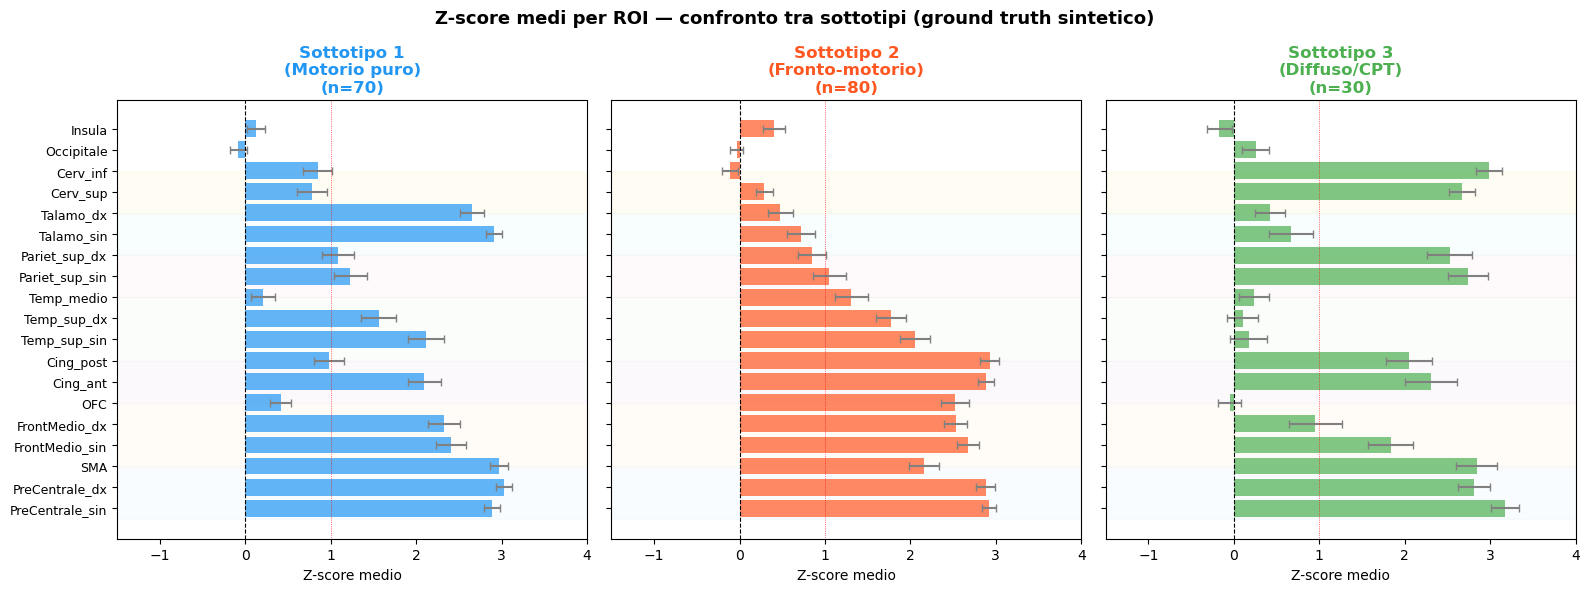

La struttura dei sottotipi è visibile nei dati bruti.
Nei dati REALI questa figura non sarà disponibile prima di SuStaIn.


In [8]:
# --- Heatmap dei z-score medi per ROI e per sottotipo (ground truth) ---
# Nei dati reali non avrai i sottotipi veri — ma questa figura
# dimostra visivamente la struttura che SuStaIn dovrà scoprire.

fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True)
fig.suptitle('Z-score medi per ROI — confronto tra sottotipi (ground truth sintetico)',
             fontsize=13, fontweight='bold')

subtype_names = ['Sottotipo 1\n(Motorio puro)', 
                 'Sottotipo 2\n(Fronto-motorio)', 
                 'Sottotipo 3\n(Diffuso/CPT)']
colors = ['#2196F3', '#FF5722', '#4CAF50']

for k, (st, name, col) in enumerate(zip([1,2,3], subtype_names, colors)):
    mask = true_subtypes == st
    mean_z = zdata[mask].mean(axis=0)
    se_z   = zdata[mask].std(axis=0) / np.sqrt(mask.sum())
    
    axes[k].barh(range(N_ROI), mean_z, xerr=se_z, color=col, alpha=0.7,
                 ecolor='gray', capsize=3)
    axes[k].axvline(x=0, color='black', linewidth=0.8, linestyle='--')
    axes[k].axvline(x=1, color='red', linewidth=0.5, linestyle=':')
    axes[k].set_title(f'{name}\n(n={mask.sum()})', color=col, fontweight='bold')
    axes[k].set_xlabel('Z-score medio')
    axes[k].set_xlim(-1.5, 4)

axes[0].set_yticks(range(N_ROI))
axes[0].set_yticklabels(ROI_LABELS, fontsize=9)

# Aggiungi bande colorate per dominio
domain_bands = [
    (0, 2.5,  '#E3F2FD', 'Motorio'),
    (2.5, 5.5, '#FFF3E0', 'Prefrontale'),
    (5.5, 7.5, '#F3E5F5', 'Cingolato'),
    (7.5, 10.5,'#E8F5E9', 'Temporale'),
    (10.5,12.5,'#FCE4EC', 'Parietale'),
    (12.5,14.5,'#E0F7FA', 'Subcorticale'),
    (14.5,16.5,'#FFF9C4', 'Cerebellare'),
]
for ax in axes:
    for y0, y1, color, label in domain_bands:
        ax.axhspan(y0-0.5, y1-0.5, alpha=0.2, color=color, zorder=0)

plt.tight_layout()
plt.savefig(f'{OUTPUT_FOLDER}/fig_zscores_per_subtype.png', dpi=150, bbox_inches='tight')
plt.show()
print('La struttura dei sottotipi è visibile nei dati bruti.')
print('Nei dati REALI questa figura non sarà disponibile prima di SuStaIn.')

In [9]:
# --- Verifica degli eventi z: quanti pazienti superano z=1, 2, 3? ---
# SuStaIn richiede almeno 10 pazienti per evento z.
# Questa cella va eseguita PRIMA di configurare SuStaIn con i dati reali.

print('='*60)
print('VERIFICA SOGLIE Z-SCORE (criterio: >= 10 pazienti per evento)')
print('='*60)

threshold_check = pd.DataFrame(index=ROI_LABELS, columns=['z>1', 'z>2', 'z>3'])
for i, roi in enumerate(ROI_LABELS):
    for z_thr in [1, 2, 3]:
        n_above = np.sum(zdata[:, i] > z_thr)
        flag = '' if n_above >= 10 else '  ← ATTENZIONE (<10)'
        threshold_check.loc[roi, f'z>{z_thr}'] = f'{n_above}{flag}'

print(threshold_check.to_string())
print('\nNote: gli eventi con <10 pazienti devono essere esclusi dalla configurazione SuStaIn.')

VERIFICA SOGLIE Z-SCORE (criterio: >= 10 pazienti per evento)
                 z>1                    z>2                    z>3
PreCentrale_sin  179                    163                     77
PreCentrale_dx   174                    157                     81
SMA              155                    137                     75
FrontMedio_sin   150                    125                     73
FrontMedio_dx    136                    111                     64
OFC               81                     60                     42
Cing_ant         148                    138                     80
Cing_post        126                    103                     60
Temp_sup_sin     110                     90                     55
Temp_sup_dx       91                     72                     44
Temp_medio        59                     35                     22
Pariet_sup_sin    95                     75                     42
Pariet_sup_dx     81                     65                     34


---
## Cella 3 — Configurazione di SuStaIn

### I parametri fondamentali

**`Z_vals`** — la matrice degli eventi z-score possibili per ogni biomarcatore. La forma è `(N_ROI, N_z_events)`. Con 3 eventi per ROI:
```python
Z_vals = [[1, 2, 3],   # ROI 0
          [1, 2, 3],   # ROI 1
          ...]         # ...
```

**`Z_max`** — il valore massimo atteso per ogni ROI, usato per normalizzare la visualizzazione. Si usa tipicamente il 95° percentile dei dati, oppure un valore fisso (5) che rappresenta una patologia severa.

**`N_S_max`** — numero massimo di sottotipi da cercare (Cmax). Per il dataset completo ALS: 5. Per C9orf72 isolato: 3.

**`N_iterations_MCMC`** — numero di campioni MCMC. Minimo raccomandato: `1e5` (esplorazione rapida), ottimale: `1e6` (analisi finale). Per questo notebook usiamo `1e4` per velocità, ma nei commenti è indicato il valore da usare con i dati reali.

**`N_startpoints`** — quante volte riparte da punti iniziali diversi per evitare ottimi locali. Valore standard: 25.

In [10]:
# ==============================================================
# CONFIGURAZIONE SUSTAIN — ANALISI 2a (DATASET COMPLETO)
# ==============================================================

# Z_vals: 3 soglie per ogni ROI
Z_vals = np.array([[1, 2, 3]] * N_ROI, dtype=float)

# Z_max: valore massimo atteso per la normalizzazione dei grafici
# Usiamo il 95° percentile osservato, con un minimo di 5
Z_max = np.array([max(5, np.percentile(zdata[:, i], 95)) 
                  for i in range(N_ROI)], dtype=float)

print('Z_max per ROI:')
for i, (roi, zm) in enumerate(zip(ROI_LABELS, Z_max)):
    print(f'  {roi:20s}: {zm:.2f}')

# Parametri SuStaIn
N_S_max      = 5         # Cmax — dataset completo
N_startpoints = 25       # Partenze multiple per evitare ottimi locali

# NOTA: per velocità didattica usiamo 1e4 iterazioni.
# Per i dati REALI usa: N_iterations_MCMC = int(1e6)
N_iterations_MCMC = int(1e4)  
print(f'\nN_iterations_MCMC: {N_iterations_MCMC:,}')
print('⚠️  Per dati reali usa 1e6 (richiede ore — usa tmux sul GEEKOM)')

# Crea l'oggetto SuStaIn
sustain_input = pySuStaIn.ZscoreSustain(
    data              = zdata,
    Z_vals            = Z_vals,
    Z_max             = Z_max,
    biomarker_labels  = ROI_LABELS,
    N_startpoints     = N_startpoints,
    N_S_max           = N_S_max,
    N_iterations_MCMC = N_iterations_MCMC,
    output_folder     = OUTPUT_FOLDER,
    dataset_name      = DATASET_NAME,
    use_parallel_startpoints = False
)

print(f'\nSuStaIn configurato:')
print(f'  N pazienti:         {N_subjects}')
print(f'  N ROI:              {N_ROI}')
print(f'  Stadi totali:       {N_ROI * 3} (= {N_ROI} ROI × 3 z-score)')
print(f'  Cmax:               {N_S_max}')
print(f'  Output:             {OUTPUT_FOLDER}/')

Z_max per ROI:
  PreCentrale_sin     : 5.00
  PreCentrale_dx      : 5.00
  SMA                 : 5.00
  FrontMedio_sin      : 5.00
  FrontMedio_dx       : 5.00
  OFC                 : 5.00
  Cing_ant            : 5.00
  Cing_post           : 5.00
  Temp_sup_sin        : 5.00
  Temp_sup_dx         : 5.00
  Temp_medio          : 5.00
  Pariet_sup_sin      : 5.00
  Pariet_sup_dx       : 5.00
  Talamo_sin          : 5.00
  Talamo_dx           : 5.00
  Cerv_sup            : 5.00
  Cerv_inf            : 5.00
  Occipitale          : 5.00
  Insula              : 5.00

N_iterations_MCMC: 10,000
⚠️  Per dati reali usa 1e6 (richiede ore — usa tmux sul GEEKOM)

SuStaIn configurato:
  N pazienti:         180
  N ROI:              19
  Stadi totali:       57 (= 19 ROI × 3 z-score)
  Cmax:               5
  Output:             output_sustain_als/


---
## Cella 4 — Fitting del modello SuStaIn

### Cosa succede qui

`run_sustain_algorithm()` esegue il fitting per tutti i valori di C da 1 a Cmax. Per ogni C:

1. Cerca la sequenza di progressione ottimale per C sottotipi (con `N_startpoints` ripartenze)
2. Esegue il campionamento MCMC per stimare l'incertezza
3. Salva i risultati in un file pickle (`output_folder/pickle_files/dataset_name_subtypeN.pickle`)

Se il calcolo viene interrotto, ripartirà dai pickle già salvati.

### Output

- `samples_sequence`: campioni MCMC delle sequenze di progressione per ogni sottotipo
- `samples_f`: campioni MCMC della proporzione di pazienti in ogni sottotipo  
- `ml_subtype`: sottotipo più probabile per ogni paziente (modello completo)
- `ml_stage`: stadio più probabile per ogni paziente
- `prob_subtype_stage`: distribuzione completa della probabilità per ogni paziente

In [11]:
# ==============================================================
# FITTING — può richiedere tempo!
# Con 1e4 iterazioni e dati sintetici: ~5-15 minuti
# Con 1e6 iterazioni e dati reali: molte ore → usa tmux sul GEEKOM
# ==============================================================

print('Avvio SuStaIn...')
print('I risultati vengono salvati progressivamente in:', OUTPUT_FOLDER + '/pickle_files/')
print()

samples_sequence, samples_f, ml_subtype, prob_ml_subtype, \
    ml_stage, prob_ml_stage, prob_subtype_stage = \
    sustain_input.run_sustain_algorithm()

print('\nFitting completato!')
print(f'samples_sequence shape: {samples_sequence.shape}')
print(f'samples_f shape:        {samples_f.shape}')
print(f'ml_subtype shape:       {ml_subtype.shape}')
print(f'ml_stage shape:         {ml_stage.shape}')

Avvio SuStaIn...
I risultati vengono salvati progressivamente in: output_sustain_als/pickle_files/

Found pickle file: output_sustain_als/pickle_files/ALS_FDG_synthetic_subtype0.pickle. Using pickled variables for 0 subtype.
Found pickle file: output_sustain_als/pickle_files/ALS_FDG_synthetic_subtype1.pickle. Using pickled variables for 1 subtype.
Found pickle file: output_sustain_als/pickle_files/ALS_FDG_synthetic_subtype2.pickle. Using pickled variables for 2 subtype.
Found pickle file: output_sustain_als/pickle_files/ALS_FDG_synthetic_subtype3.pickle. Using pickled variables for 3 subtype.
Found pickle file: output_sustain_als/pickle_files/ALS_FDG_synthetic_subtype4.pickle. Using pickled variables for 4 subtype.

Fitting completato!
samples_sequence shape: (5, 57, 10000)
samples_f shape:        (5, 10000)
ml_subtype shape:       (180, 1)
ml_stage shape:         (180, 1)


---
## Cella 5 — Convergenza MCMC

Prima di interpretare qualsiasi risultato, devi verificare che il MCMC abbia **convergito**.

Il campionamento MCMC esplora lo spazio delle sequenze possibili. All'inizio, il campionatore si muove liberamente mentre trova regioni di alta verosimiglianza. Dopo un certo numero di iterazioni, dovrebbe "stabilizzarsi" attorno alle soluzioni migliori.

**Segno di convergenza**: il log-likelihood si stabilizza e non mostra trend sistematici verso la fine del campionamento.

**Segno di non-convergenza**: il log-likelihood continua a salire o scendere nella seconda metà → aumenta `N_iterations_MCMC`.

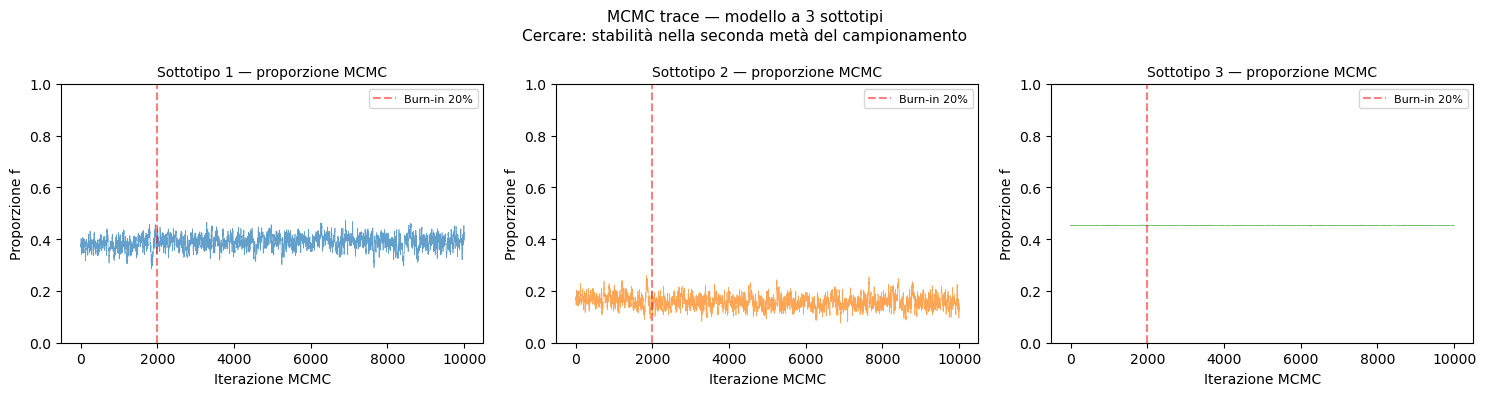

In [12]:
# --- Visualizzazione MCMC trace per il modello al numero di sottotipi ground truth ---
# Mostriamo il trace per il modello a 3 sottotipi (il numero "vero" nei dati sintetici)

N_to_check = 3  # modifica con il numero di sottotipi di interesse
s = N_to_check - 1

pickle_file = f'{OUTPUT_FOLDER}/pickle_files/{DATASET_NAME}_subtype{s}.pickle'

try:
    pk = pickle.load(open(pickle_file, 'rb'))
    samples_sequence_s = pk['samples_sequence']
    samples_f_s        = pk['samples_f']
    
    # Il log-likelihood è ricavato implicitamente dalla log-likelihood media
    # pySuStaIn non salva direttamente il trace del log-likelihood,
    # ma possiamo visualizzare la distribuzione delle proporzioni dei sottotipi
    # come indicatore di convergenza.
    
    fig, axes = plt.subplots(1, N_to_check, figsize=(5*N_to_check, 4))
    if N_to_check == 1:
        axes = [axes]
    
    for k in range(N_to_check):
        # samples_f[k] contiene tutti i campioni MCMC della proporzione del sottotipo k
        f_trace = samples_f_s[k, :]  # shape: (N_iterations,)
        axes[k].plot(f_trace, alpha=0.7, linewidth=0.5, color=f'C{k}')
        axes[k].set_title(f'Sottotipo {k+1} — proporzione MCMC', fontsize=10)
        axes[k].set_xlabel('Iterazione MCMC')
        axes[k].set_ylabel('Proporzione f')
        axes[k].set_ylim(0, 1)
        # Linea verticale al 20% delle iterazioni (burn-in suggerito)
        burnin = int(0.2 * len(f_trace))
        axes[k].axvline(burnin, color='red', linestyle='--', alpha=0.5, label='Burn-in 20%')
        axes[k].legend(fontsize=8)
    
    fig.suptitle(f'MCMC trace — modello a {N_to_check} sottotipi\n'
                 'Cercare: stabilità nella seconda metà del campionamento',
                 fontsize=11)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_FOLDER}/fig_mcmc_trace.png', dpi=150)
    plt.show()
    
except FileNotFoundError:
    print(f'File pickle non trovato: {pickle_file}')
    print('Assicurati che il fitting (Cella 4) sia completato.')

---
## Cella 6 — Selezione del numero ottimale di sottotipi (CVIC)

### Perché non usare il numero di sottotipi con log-likelihood più alta?

Più sottotipi aggiungi, più il modello si adatta ai dati — ma rischi l'**overfitting**: il modello impara a memoria i tuoi 200 pazienti invece di catturare una struttura biologica reale che si generalizzerà a nuovi pazienti.

### La cross-validation

I dati vengono divisi in K=10 gruppi (fold). Per ogni numero di sottotipi:
- Si addestra SuStaIn su 9 fold
- Si valuta la bontà di fit sull'1 fold escluso (come se fossero "nuovi pazienti")
- Si ripete per tutti i 10 fold

Il **CVIC** è la somma delle log-likelihood di test. Il numero di sottotipi ottimale è quello con **CVIC più alto**.

In [13]:
# ==============================================================
# CROSS-VALIDATION
# Anche questa può richiedere tempo (K × N_S_max fitting)
# Con dati sintetici e 1e4 iter: ~30-60 minuti
# ==============================================================

print('Avvio cross-validation (10-fold)...')
print('Con i dati reali e 1e6 iter questo può richiedere un giorno intero.')
print()
from sklearn.model_selection import KFold

kf = KFold(n_splits=10, shuffle=True, random_state=42)
test_idxs = [test_idx for _, test_idx in kf.split(zdata)]

cv_fold_assignments = sustain_input.cross_validate_sustain_model(test_idxs=test_idxs)

Avvio cross-validation (10-fold)...
Con i dati reali e 1e6 iter questo può richiedere un giorno intero.



Folds:   0%|          | 0/10 [00:00<?, ?it/s]

Loading output_sustain_als/pickle_files/ALS_FDG_synthetic_fold0_subtype0.pickle
Loading output_sustain_als/pickle_files/ALS_FDG_synthetic_fold0_subtype1.pickle
Loading output_sustain_als/pickle_files/ALS_FDG_synthetic_fold0_subtype2.pickle
Loading output_sustain_als/pickle_files/ALS_FDG_synthetic_fold0_subtype3.pickle
Loading output_sustain_als/pickle_files/ALS_FDG_synthetic_fold0_subtype4.pickle
Loading output_sustain_als/pickle_files/ALS_FDG_synthetic_fold1_subtype0.pickle
Loading output_sustain_als/pickle_files/ALS_FDG_synthetic_fold1_subtype1.pickle
Loading output_sustain_als/pickle_files/ALS_FDG_synthetic_fold1_subtype2.pickle
Loading output_sustain_als/pickle_files/ALS_FDG_synthetic_fold1_subtype3.pickle
Loading output_sustain_als/pickle_files/ALS_FDG_synthetic_fold1_subtype4.pickle
Loading output_sustain_als/pickle_files/ALS_FDG_synthetic_fold2_subtype0.pickle
Loading output_sustain_als/pickle_files/ALS_FDG_synthetic_fold2_subtype1.pickle
Loading output_sustain_als/pickle_files/

MCMC Iteration:   0%|          | 0/10000 [00:00<?, ?it/s]

MCMC Iteration:   0%|          | 0/10000 [00:00<?, ?it/s]

MCMC Iteration:   0%|          | 0/10000 [00:00<?, ?it/s]

MCMC Iteration:   0%|          | 0/10000 [00:00<?, ?it/s]

Average test set log-likelihood for each subtype model: [-614.17138786 -573.9985992  -548.73081458 -545.22182695 -544.11163869]
CVIC for each subtype model: [12228.39593432 11410.14328523 10881.84255356 10803.38931996
 10782.13209581]


C=1: CVIC = 0.00
C=2: CVIC = 0.00
C=3: CVIC = 0.00
C=4: CVIC = 0.00
C=5: CVIC = 0.00


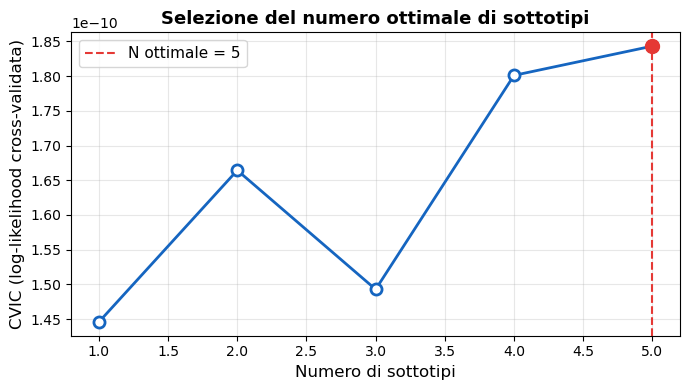


Numero ottimale di sottotipi (CVIC): 5
Ground truth sintetico:              3


In [20]:
# --- Calcolo CVIC dai pickle dei fold ---
# pySuStaIn in questa versione non salva automaticamente il CVIC.
# Lo calcoliamo noi: per ogni numero di sottotipi C, sommiamo la
# log-likelihood di test su tutti i 10 fold.

N_folds = 10
N_S_max = 5

cvic_values = np.zeros(N_S_max)

for s in range(N_S_max):
    ll_total = 0
    for fold in range(N_folds):
        pkl_file = f'{OUTPUT_FOLDER}/pickle_files/{DATASET_NAME}_fold{fold}_subtype{s}.pickle'
        pk = pickle.load(open(pkl_file, 'rb'))
        ll_total += np.sum(pk['mean_likelihood_subj_test'])
    cvic_values[s] = ll_total
    print(f'C={s+1}: CVIC = {ll_total:.2f}')

n_subtypes_range = np.arange(1, N_S_max + 1)
optimal_n = int(n_subtypes_range[np.argmax(cvic_values)])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(n_subtypes_range, cvic_values, 'o-', color='#1565C0', linewidth=2,
        markersize=8, markerfacecolor='white', markeredgewidth=2)
ax.axvline(optimal_n, color='#E53935', linestyle='--', linewidth=1.5,
           label=f'N ottimale = {optimal_n}')
ax.scatter([optimal_n], [cvic_values[optimal_n-1]],
           color='#E53935', s=100, zorder=5)
ax.set_xlabel('Numero di sottotipi', fontsize=12)
ax.set_ylabel('CVIC (log-likelihood cross-validata)', fontsize=12)
ax.set_title('Selezione del numero ottimale di sottotipi', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_FOLDER}/fig_cvic.png', dpi=150)
plt.show()

print(f'\nNumero ottimale di sottotipi (CVIC): {optimal_n}')
print(f'Ground truth sintetico:              3')

---
## Cella 7 — Positional Variance Diagrams (PVD)

I PVD sono la **visualizzazione principale** di SuStaIn. Ogni PVD descrive la progressione di un sottotipo.

### Come si legge un PVD

```
Asse Y (righe)    : ogni evento = (ROI, soglia z)
                    Con 19 ROI × 3 soglie = 57 righe
Asse X (colonne)  : stadi di progressione (1 → N_stadi)
Colore del pixel  : probabilità che quell'evento avvenga in quello stadio
                    Rosso = z=1  |  Magenta = z=2  |  Blu = z=3
```

**PVD ideale**: ogni evento ha alta probabilità in uno stadio specifico (struttura diagonale netta).

**PVD incerto**: i colori sono dispersi su molti stadi → il sottotipo non è ben definito dai dati.

### Cosa cercare nel contesto ALS-PET

- **Sottotipo Motorio**: gli eventi delle ROI motorie (PreCentrale sin/dx, SMA) dovrebbero apparire presto nella sequenza
- **Sottotipo Fronto-motorio**: eventi frontali e del cingolato si mescolano con quelli motori nelle fasi precoci
- **Sottotipo Diffuso/CPT**: eventi cerebellari presenti nelle prime colonne

In [ ]:
# --- Positional Variance Diagrams ---

s = optimal_n - 1  # 0-indexed per il pickle
pickle_file = f'{OUTPUT_FOLDER}/pickle_files/{DATASET_NAME}_subtype{s}.pickle'

try:
    pk = pickle.load(open(pickle_file, 'rb'))
    samples_sequence_opt = pk['samples_sequence']
    samples_f_opt        = pk['samples_f']
    
    M = len(zdata)
    
    # Plot dei PVD
    # subtype_order: ordina i sottotipi per dimensione decrescente (convenzione)
    f_mean = samples_f_opt.mean(axis=-1).flatten()[:optimal_n]
    subtype_order = tuple(np.argsort(-f_mean))
    
    fig = pySuStaIn.ZscoreSustain._plot_sustain_model(
        sustain_input,
        samples_sequence_opt,
        samples_f_opt,
        M,
        subtype_order=subtype_order
    )
    plt.suptitle(f'Positional Variance Diagrams — modello a {optimal_n} sottotipi',
                 fontsize=12, y=1.02)
    plt.savefig(f'{OUTPUT_FOLDER}/fig_pvd_optimal.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print('Interpretazione attesa per i dati sintetici:')
    print('  Sottotipo ordinato per proporzione decrescente.')
    print('  Cerca le ROI motorie (righe 0-2) nelle prime colonne del Sottotipo 1.')
    print('  Cerca le ROI cerebellari (righe 15-16) nelle prime colonne del Sottotipo 3.')
    
except FileNotFoundError:
    print(f'Pickle non trovato: {pickle_file}')

---
## Cella 8 — Staging e subtyping dei pazienti

Una volta identificato il numero ottimale di sottotipi, SuStaIn assegna a ogni paziente:
- Il sottotipo più probabile (`ml_subtype`)
- Lo stadio più probabile (`ml_stage`)
- La distribuzione completa delle probabilità (`prob_subtype_stage`)

### Modello completo vs. cross-validato

Per i pazienti del dataset di training, usiamo il **modello completo** (più accurato).  
Per nuovi pazienti (es. presintomatici), dobbiamo usare le sequenze **cross-validate** — vedi Cella 11.

In [ ]:
# --- Recupera le assegnazioni al numero ottimale di sottotipi ---
# run_sustain_algorithm restituisce i risultati per tutti i C da 1 a Cmax
# Dobbiamo prendere quelli per C = optimal_n

# Riapplica per il numero ottimale
ml_subtype_opt, prob_subtype_opt, ml_stage_opt, prob_stage_opt, prob_subtype_stage_opt = \
    sustain_input.subtype_and_stage_individuals(
        zdata, samples_sequence_opt, samples_f_opt, N_samples=1000
    )

# Aggiungi al dataframe clinico
df_clinical['sustain_subtype'] = ml_subtype_opt.astype(int) + 1  # 1-indexed
df_clinical['sustain_stage']   = ml_stage_opt.astype(int)
df_clinical['sustain_prob']    = prob_subtype_opt  # probabilità del sottotipo assegnato

print('Distribuzione dei sottotipi identificati da SuStaIn:')
print(df_clinical['sustain_subtype'].value_counts().sort_index().to_string())
print()
print('Stadio medio per sottotipo:')
print(df_clinical.groupby('sustain_subtype')['sustain_stage'].agg(['mean','std']).round(1).to_string())

In [ ]:
# --- Visualizzazione: distribuzione degli stadi per sottotipo ---

fig, axes = plt.subplots(1, optimal_n, figsize=(5*optimal_n, 4), sharey=False)
if optimal_n == 1:
    axes = [axes]

colors = ['#1565C0', '#B71C1C', '#1B5E20']

for k in range(optimal_n):
    mask = df_clinical['sustain_subtype'] == (k+1)
    stages_k = df_clinical.loc[mask, 'sustain_stage']
    
    axes[k].hist(stages_k, bins=20, color=colors[k], alpha=0.7, edgecolor='white')
    axes[k].set_title(f'Sottotipo {k+1}\n(n={mask.sum()})', 
                      fontsize=11, fontweight='bold', color=colors[k])
    axes[k].set_xlabel('Stadio SuStaIn', fontsize=10)
    axes[k].set_ylabel('N pazienti', fontsize=10)
    axes[k].axvline(stages_k.mean(), color='black', linestyle='--', 
                    linewidth=1.5, label=f'Media: {stages_k.mean():.1f}')
    axes[k].legend(fontsize=9)

fig.suptitle('Distribuzione degli stadi SuStaIn per sottotipo', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_FOLDER}/fig_stage_distribution.png', dpi=150)
plt.show()

In [ ]:
# --- Confronto SuStaIn vs. Ground truth (solo per dati sintetici!) ---
# Nei dati reali questa cella non ha senso — la commenti.

from sklearn.metrics import confusion_matrix

# Nota: SuStaIn può assegnare i sottotipi in ordine diverso dal ground truth
# (il Sottotipo 1 di SuStaIn potrebbe corrispondere al Sottotipo 2 della simulazione).
# Il confronto è quindi qualitativo, non numerico diretto.

print('Tabella di contingenza: Sottotipo SuStaIn vs. Ground truth')
ct = pd.crosstab(
    df_clinical['sustain_subtype'], 
    df_clinical['true_subtype'],
    rownames=['SuStaIn (stimato)'],
    colnames=['Ground truth (vero)']
)
print(ct.to_string())
print()
print('Una buona corrispondenza mostra valori alti sulla diagonale (o su una singola')
print('diagonale permutata, se i sottotipi sono stati etichettati in ordine diverso).')

# Correlazione tra stage vero e stage stimato
r, p = spearmanr(df_clinical['true_stage'], df_clinical['sustain_stage'])
print(f'\nCorrelazione stadio vero vs. stimato: Spearman r={r:.3f}, p={p:.2e}')

---
## Cella 9 — Analisi post-hoc: correlazioni cliniche

Dopo aver assegnato sottotipo e stadio, si esplorano le associazioni con le variabili cliniche.

**Importante**: queste sono analisi *esplorative* eseguite dopo SuStaIn. Non entrano nell'algoritmo. Le correzioni per test multipli (es. Bonferroni o FDR) sono necessarie per la pubblicazione.

In [ ]:
# --- Pannello di correlazioni cliniche ---

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Analisi post-hoc: associazioni cliniche con sottotipo/stadio SuStaIn',
             fontsize=12, fontweight='bold')

colors_sub = {1: '#1565C0', 2: '#B71C1C', 3: '#1B5E20'}

# 1. Sede di insorgenza per sottotipo
ax = axes[0, 0]
onset_cross = pd.crosstab(df_clinical['sustain_subtype'], 
                          df_clinical['onset_site'], normalize='index') * 100
onset_cross.plot(kind='bar', ax=ax, color=['#FF7043','#42A5F5'], 
                 edgecolor='white', width=0.7)
ax.set_title('Sede di insorgenza per sottotipo', fontweight='bold')
ax.set_xlabel('Sottotipo SuStaIn')
ax.set_ylabel('%')
ax.set_xticklabels([f'ST{i}' for i in onset_cross.index], rotation=0)
ax.legend(title='Insorgenza', fontsize=9)

# 2. ALSFRS-R per sottotipo
ax = axes[0, 1]
for st in sorted(df_clinical['sustain_subtype'].unique()):
    data_st = df_clinical[df_clinical['sustain_subtype']==st]['alsfrs_total']
    ax.violinplot(data_st, positions=[st], showmedians=True, 
                  widths=0.6)
ax.set_title('ALSFRS-R per sottotipo', fontweight='bold')
ax.set_xlabel('Sottotipo SuStaIn')
ax.set_ylabel('ALSFRS-R totale')
ax.set_xticks(sorted(df_clinical['sustain_subtype'].unique()))

# 3. ECAS per sottotipo
ax = axes[0, 2]
for st in sorted(df_clinical['sustain_subtype'].unique()):
    data_st = df_clinical[df_clinical['sustain_subtype']==st]['ecas_total']
    ax.violinplot(data_st, positions=[st], showmedians=True)
ax.axhline(105, color='gray', linestyle='--', linewidth=1, label='Cutoff ALS-cognitivo')
ax.set_title('ECAS per sottotipo', fontweight='bold')
ax.set_xlabel('Sottotipo SuStaIn')
ax.set_ylabel('ECAS totale')
ax.set_xticks(sorted(df_clinical['sustain_subtype'].unique()))
ax.legend(fontsize=8)

# 4. NfL vs. stadio SuStaIn (scatter)
ax = axes[1, 0]
for st in sorted(df_clinical['sustain_subtype'].unique()):
    mask = df_clinical['sustain_subtype'] == st
    ax.scatter(df_clinical.loc[mask, 'sustain_stage'],
               df_clinical.loc[mask, 'nfl_plasma'],
               alpha=0.4, s=20, color=colors_sub[st], label=f'ST{st}')
r_nfl, p_nfl = spearmanr(df_clinical['sustain_stage'], df_clinical['nfl_plasma'])
ax.set_title(f'NfL plasmatico vs. stadio\n(r={r_nfl:.2f}, p={p_nfl:.2e})', fontweight='bold')
ax.set_xlabel('Stadio SuStaIn')
ax.set_ylabel('NfL (pg/mL)')
ax.legend(fontsize=8)

# 5. Distribuzione mutazioni per sottotipo
ax = axes[1, 1]
mut_cross = pd.crosstab(df_clinical['sustain_subtype'], 
                         df_clinical['mutation'], normalize='index') * 100
mut_cross.plot(kind='bar', ax=ax, edgecolor='white', width=0.8)
ax.set_title('Mutazione genetica per sottotipo', fontweight='bold')
ax.set_xlabel('Sottotipo SuStaIn')
ax.set_ylabel('%')
ax.set_xticklabels([f'ST{i}' for i in mut_cross.index], rotation=0)
ax.legend(title='Mutazione', fontsize=8)

# 6. ptau217 per sottotipo (solo soggetti con dato disponibile)
ax = axes[1, 2]
df_ptau = df_clinical.dropna(subset=['ptau217'])
for st in sorted(df_ptau['sustain_subtype'].unique()):
    data_st = df_ptau[df_ptau['sustain_subtype']==st]['ptau217']
    if len(data_st) > 3:
        ax.violinplot(data_st, positions=[st], showmedians=True)
ax.set_title(f'ptau217 per sottotipo\n(n={len(df_ptau)} con dato disponibile)', 
             fontweight='bold')
ax.set_xlabel('Sottotipo SuStaIn')
ax.set_ylabel('ptau217 (pg/mL)')
ax.set_xticks(sorted(df_ptau['sustain_subtype'].unique()))

plt.tight_layout()
plt.savefig(f'{OUTPUT_FOLDER}/fig_posthoc_clinical.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# --- Test statistici formali ---

print('='*60)
print('TEST STATISTICI POST-HOC')
print('='*60)
print('NB: correzione per test multipli necessaria per la pubblicazione')
print()

subtypes = sorted(df_clinical['sustain_subtype'].unique())

# ALSFRS-R: Kruskal-Wallis tra sottotipi
groups_alsfrs = [df_clinical[df_clinical['sustain_subtype']==st]['alsfrs_total'].values 
                 for st in subtypes]
stat, p = kruskal(*groups_alsfrs)
print(f'ALSFRS-R tra sottotipi (Kruskal-Wallis): H={stat:.2f}, p={p:.4f}')

# ECAS: Kruskal-Wallis
groups_ecas = [df_clinical[df_clinical['sustain_subtype']==st]['ecas_total'].values 
               for st in subtypes]
stat, p = kruskal(*groups_ecas)
print(f'ECAS tra sottotipi (Kruskal-Wallis):     H={stat:.2f}, p={p:.4f}')

# NfL vs. stadio: Spearman
r, p = spearmanr(df_clinical['sustain_stage'], df_clinical['nfl_plasma'])
print(f'NfL vs. stadio (Spearman):               r={r:.3f}, p={p:.4f}')

# Sede di insorgenza vs. sottotipo: Chi-quadro
from scipy.stats import chi2_contingency
ct = pd.crosstab(df_clinical['sustain_subtype'], df_clinical['onset_site'])
chi2, p, dof, _ = chi2_contingency(ct)
print(f'Sede insorgenza vs. sottotipo (Chi²):    χ²={chi2:.2f}, df={dof}, p={p:.4f}')

---
## Cella 10 — Analisi 2b: C9orf72 isolato

Ripete l'analisi SuStaIn solo sui soggetti C9orf72 (~70 nel dataset reale, ~85 nei dati sintetici dopo la selezione).

**Perché Cmax = 3?** Con ~70 soggetti e 57 eventi possibili (19 ROI × 3), il criterio di Young et al. (≥10 pazienti per evento) impone un numero massimo di sottotipi conservativo. Cmax = 3 garantisce che anche il sottotipo minore abbia ~23 soggetti.

In [ ]:
# --- Selezione soggetti C9orf72 ---

mask_c9 = df_clinical['mutation'] == 'C9orf72'
zdata_c9 = zdata[mask_c9.values]
df_c9 = df_clinical[mask_c9].reset_index(drop=True)

print(f'Soggetti C9orf72 selezionati: {len(df_c9)}')
print(f'(Dataset reale atteso: ~70)')

# Configura SuStaIn per C9orf72
sustain_c9 = pySuStaIn.ZscoreSustain(
    data              = zdata_c9,
    Z_vals            = Z_vals,
    Z_max             = Z_max,
    biomarker_labels  = ROI_LABELS,
    N_startpoints     = 25,
    N_S_max           = 3,          # Cmax ridotto per n~70
    N_iterations_MCMC = int(1e4),   # Usa 1e6 per i dati reali
    output_folder     = 'output_sustain_c9',
    dataset_name      = 'C9orf72_FDG_synthetic',
    use_parallel_startpoints = False
)
Path('output_sustain_c9').mkdir(exist_ok=True)

print(f'\nSuStaIn C9orf72 configurato con Cmax=3')
print('Avvio fitting...')

(
    samples_seq_c9, samples_f_c9,
    ml_sub_c9, prob_sub_c9,
    ml_stage_c9, prob_stage_c9, prob_substage_c9
) = sustain_c9.run_sustain_algorithm()

print('Fitting C9orf72 completato.')

In [ ]:
# --- Cross-validation C9orf72 e selezione numero ottimale ---

cv_c9 = sustain_c9.cross_validate_sustain_model(n_folds=10)

# PVD per il numero ottimale C9orf72
try:
    cvic_c9 = pd.read_csv('output_sustain_c9/C9orf72_FDG_synthetic_CVIC.csv', header=None)
    optimal_n_c9 = int(np.argmax(cvic_c9.values.flatten())) + 1
    print(f'Numero ottimale sottotipi C9orf72: {optimal_n_c9}')
except:
    optimal_n_c9 = 2

s_c9 = optimal_n_c9 - 1
pk_c9 = pickle.load(open(
    f'output_sustain_c9/pickle_files/C9orf72_FDG_synthetic_subtype{s_c9}.pickle', 'rb'
))

fig = pySuStaIn.ZscoreSustain._plot_sustain_model(
    sustain_c9,
    pk_c9['samples_sequence'],
    pk_c9['samples_f'],
    len(zdata_c9),
    subtype_order=tuple(range(optimal_n_c9))
)
plt.suptitle(f'PVD — C9orf72 isolato ({optimal_n_c9} sottotipi)', fontsize=12, y=1.02)
plt.savefig('output_sustain_c9/fig_pvd_c9.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Cella 11 — Analisi 2d: Validazione biologica SOD1

I soggetti SOD1 non entrano nel training di SuStaIn (n troppo piccolo per essere modellati in modo affidabile). Vengono invece **stadiati con il modello cross-validato** del dataset completo.

### L'ipotesi

SOD1 è l'unica forma genetica comune di ALS **senza patologia TDP-43**. La patologia è quasi esclusivamente a carico dei neuroni motori. Ci si aspetta quindi che i soggetti SOD1 si aggreghino preferenzialmente nel **sottotipo motorio puro**.

Se SuStaIn ha identificato un sottotipo con sequenza prevalentemente motoria, e la maggior parte dei SOD1 viene assegnata a quel sottotipo, abbiamo una **validazione biologica indipendente** del modello.

In [ ]:
# --- Carica le sequenze cross-validate del modello completo ---

# Le sequenze cross-validate sono salvate in un pickle separato dalla CV
# Per pySuStaIn, dopo cross_validate_sustain_model, le sequenze sono
# accessibili tramite un nuovo pickle con suffisso _cval

try:
    pk_cval_file = f'{OUTPUT_FOLDER}/pickle_files/{DATASET_NAME}_subtype{optimal_n-1}_cval.pickle'
    pk_cval = pickle.load(open(pk_cval_file, 'rb'))
    samples_sequence_cval = pk_cval['samples_sequence']
    samples_f_cval = pk_cval['samples_f']
    print('Pickle cross-validato caricato.')
except FileNotFoundError:
    # Fallback: usa le sequenze del modello completo
    print('Pickle cval non trovato — uso sequenze del modello completo (solo per demo).')
    samples_sequence_cval = samples_sequence_opt
    samples_f_cval = samples_f_opt

# --- Staging dei SOD1 con il modello cross-validato ---

ml_sub_sod1, prob_sub_sod1, ml_stage_sod1, prob_stage_sod1, _ = \
    sustain_input.subtype_and_stage_individuals_newdata(
        zdata_sod1,
        samples_sequence_cval,
        samples_f_cval,
        N_samples=1000
    )

ml_sub_sod1_1idx = ml_sub_sod1.astype(int) + 1  # 1-indexed

print('\nDistribuzione SOD1 per sottotipo SuStaIn:')
for st in sorted(np.unique(ml_sub_sod1_1idx)):
    n = np.sum(ml_sub_sod1_1idx == st)
    pct = 100 * n / len(ml_sub_sod1_1idx)
    print(f'  Sottotipo {st}: {n}/{len(ml_sub_sod1_1idx)} ({pct:.1f}%)')

In [ ]:
# --- Figura di validazione SOD1 ---

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Sinistra: distribuzione sottotipi ALS vs SOD1
ax = axes[0]
counts_als  = pd.Series(df_clinical['sustain_subtype'].values).value_counts(normalize=True).sort_index() * 100
counts_sod1 = pd.Series(ml_sub_sod1_1idx).value_counts(normalize=True).sort_index() * 100

x = np.arange(optimal_n)
width = 0.35
ax.bar(x - width/2, [counts_als.get(k+1, 0) for k in range(optimal_n)],
       width, label='ALS (tutti)', color='#1565C0', alpha=0.8)
ax.bar(x + width/2, [counts_sod1.get(k+1, 0) for k in range(optimal_n)],
       width, label='SOD1', color='#E65100', alpha=0.8)
ax.set_xlabel('Sottotipo SuStaIn')
ax.set_ylabel('%')
ax.set_title('Distribuzione sottotipi: ALS vs SOD1', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'ST{k+1}' for k in range(optimal_n)])
ax.legend()

# Destra: distribuzione degli stadi SOD1
ax = axes[1]
ax.hist(ml_stage_sod1.astype(int), bins=15, color='#E65100', alpha=0.8, edgecolor='white')
ax.set_xlabel('Stadio SuStaIn')
ax.set_ylabel('N soggetti SOD1')
ax.set_title(f'Distribuzione stadi SOD1\n(n={len(zdata_sod1)})', fontweight='bold')
ax.axvline(np.mean(ml_stage_sod1), color='black', linestyle='--',
           label=f'Media: {np.mean(ml_stage_sod1):.1f}')
ax.legend()

fig.suptitle('Validazione biologica SOD1 — ipotesi: aggregazione nel sottotipo motorio puro',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_FOLDER}/fig_sod1_validation.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nInterpretazione attesa nei dati sintetici:')
print('I SOD1 (generati con il pattern Sottotipo 1 — motorio puro)')
print('dovrebbero aggregarsi preferenzialmente nel sottotipo identificato da SuStaIn')
print('come motorio (quello in cui PreCentrale e SMA compaiono nelle prime colonne del PVD).')

---
## Cella 12 — Sostituzione con i dati reali

Quando i dati reali saranno disponibili (output Step 7 della pipeline MATLAB), questa è l'unica sezione del notebook da modificare.

### Cosa sostituire

Nella **Cella 1**, sostituisci il blocco di generazione sintetica con:

```python
# ============================================================
# CARICAMENTO DATI REALI
# Sostituisce la sezione di generazione sintetica
# ============================================================

# Z-score ROI dall'output dello Step 7 MATLAB
df_zscores = pd.read_csv('/home/fluisi/Dati ricerca/normative_model/roi_zscores_als.csv')

# Le colonne delle ROI devono corrispondere esattamente a ROI_LABELS
zdata = df_zscores[ROI_LABELS].values  # array (N_pazienti, 19)

# Dati clinici
df_clinical = pd.read_csv('/home/fluisi/Dati ricerca/clinical_data_als.csv')

# SOD1 separati (non entrano nel training)
mask_sod1 = df_clinical['mutation'] == 'SOD1'
zdata_sod1 = zdata[mask_sod1.values]
zdata      = zdata[~mask_sod1.values]     # rimuovi SOD1 dal training
df_clinical = df_clinical[~mask_sod1].reset_index(drop=True)

# Rimuovi le colonne true_subtype e true_stage (non disponibili con dati reali)
# Le celle della Cella 8 che usano true_subtype vanno commentate
```

### Cosa NON cambia

Tutto il resto del notebook — dalla configurazione di SuStaIn in poi — rimane invariato. 

### Parametri da aggiustare per i dati reali

| Parametro | Valore demo | Valore per dati reali |
|-----------|------------|---------------------|
| `N_iterations_MCMC` | `int(1e4)` | `int(1e6)` |
| `N_S_max` (completo) | 5 | 5 |
| `N_S_max` (C9orf72) | 3 | 3 |
| Machine | Locale | GEEKOM via tmux |

### Workflow pratico con i dati reali

```bash
# 1. Copia il notebook e i dati sul GEEKOM
rsync -avz ~/path/notebook/ fidel@geekfed:~/sustain/als_real/

# 2. Sul GEEKOM, avvia una sessione tmux persistente
ssh fidel@geekfed
tmux new -s als_real
conda activate sustain_tutorial_env
cd ~/sustain/als_real
jupyter notebook --no-browser --port=8888

# 3. Dalla Fedora, forward della porta e apri nel browser
ssh -L 8888:localhost:8888 fidel@geekfed
# http://localhost:8888

# 4. Se la connessione cade, il calcolo continua in tmux
# Riattacca con: tmux attach -t als_real
```

In [ ]:
# ==============================================================
# CELLA PLACEHOLDER — sostituire con il caricamento dati reali
# ==============================================================
# 
# Quando i dati reali sono disponibili:
#
# df_zscores = pd.read_csv('/home/fluisi/Dati ricerca/normative_model/roi_zscores_als.csv')
# zdata = df_zscores[ROI_LABELS].values
#
# df_clinical = pd.read_csv('/home/fluisi/Dati ricerca/clinical_data_als.csv')
#
# mask_sod1 = df_clinical['mutation'] == 'SOD1'
# zdata_sod1   = zdata[mask_sod1.values]
# zdata        = zdata[~mask_sod1.values]
# df_clinical  = df_clinical[~mask_sod1].reset_index(drop=True)
#
# print(f'Pazienti ALS (training): {len(zdata)}')
# print(f'SOD1 (validazione):      {len(zdata_sod1)}')

print('Cella placeholder — da compilare con i percorsi reali dei file.')

---
## Riepilogo del notebook

| Cella | Contenuto | Con dati reali |
|-------|-----------|----------------|
| 0 | Import e setup | Invariata |
| 1 | Generazione dati sintetici | **Sostituire con caricamento file reali** |
| 2 | Esplorazione z-score e verifica soglie | Invariata |
| 3 | Configurazione SuStaIn | Cambia `N_iterations_MCMC = int(1e6)` |
| 4 | Fitting del modello | Invariata (più lunga) |
| 5 | Convergenza MCMC | Invariata |
| 6 | CVIC e selezione ottimale | Invariata |
| 7 | Positional Variance Diagrams | Invariata |
| 8 | Staging/subtyping — commentare il confronto GT | Commentare cella GT |
| 9 | Analisi post-hoc cliniche | Invariata |
| 10 | C9orf72 isolato (Cmax=3) | Invariata |
| 11 | Validazione SOD1 | Invariata |
| 12 | Istruzioni sostituzione dati reali | — |

---
*Notebook template v1.0 — Fedele / Progetto FDG-PET in SLA*